# **Lab Report ___ BOUHOUIA Yousra G1**

# Motion Analysis - Object Tracking

## Introduction

The goal of this exercise is to get familiar with the basic concepts of visual object tracking. As in the lectures, we will focus on model-free single-object online tracking: we will analyze the video sequence frame by frame and localize the target object. We will visualize the results using Matplotlib. The last part of the exercise will also look at the basics of performance evaluation of tracking algorithms.

We will be using all the libraries that you are already familiar with: OpenCV, NumPy and Matplotlib.

In [2]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt

## 1. Read the video and visualize the frames

In this task, we will read a video file and visualize the first few frames. We will use OpenCV to read the video and Matplotlib to display the frames. Suitable video files are provided in the `data` folder. As it is common in computer vision (for compatibility and reproducibility reasons), videos are stored on a per-frame basis, each frame is a separate image file. We will use a simple loader that scans the folder and loads the images in the correct order. 

In [3]:

def load_video(video_path):
    """
    Load a video from a directory and return a list of frames. Each frame is a JPEG image, they are numbered with zero padded integers.
    """
    import cv2
    import os

    i = 1
    
    video = []
    
    while True:
        image_path = os.path.join(video_path, f"{i:08d}.jpg")
        if not os.path.exists(image_path):
            break
        image = cv2.imread(image_path)
        if image is None:
            break
        video.append(image)
        i += 1
        
    return video


Use the function above to load the video frames and display **ten approximately uniformly sampled frames** using Matplotlib. You can use the `imshow` function to display the images and `subplots` to create a grid of images. Make sure to set the title of each subplot to indicate the frame number.

**Task:** write the loading, sampling, and visualization code below.

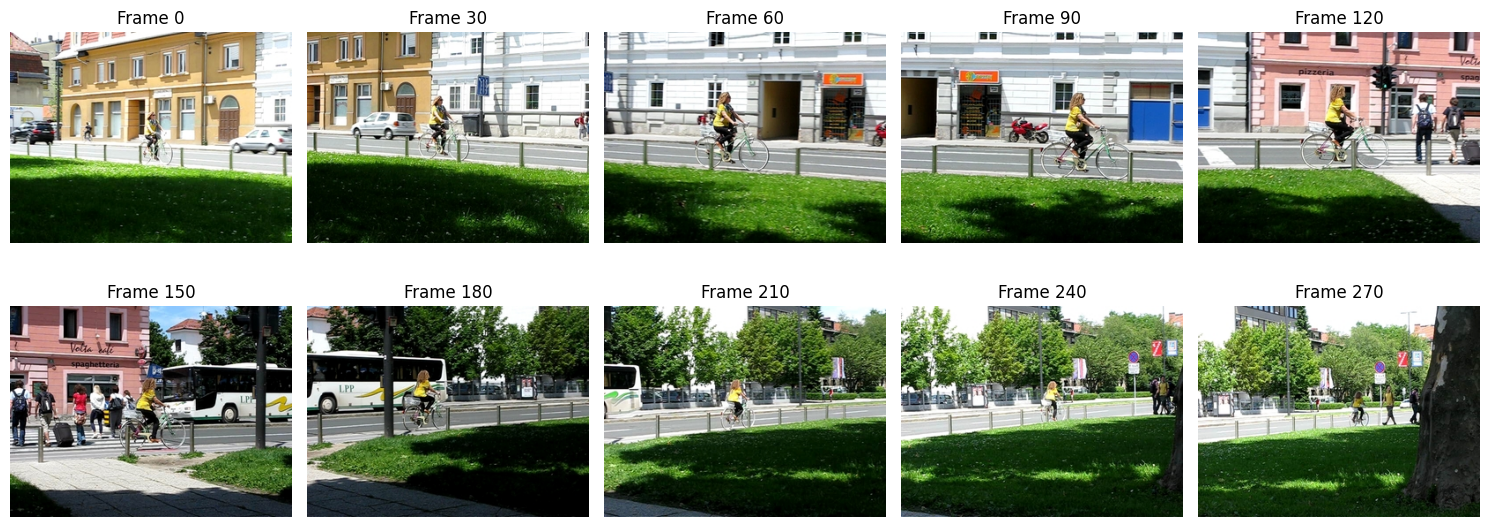

In [4]:
video = load_video("data/bicycle/")

idxs = np.linspace(0, len(video) - 1, 10, dtype=int)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, idx in zip(axes.ravel(), idxs):
    frame_rgb = cv2.cvtColor(video[idx], cv2.COLOR_BGR2RGB)
    ax.imshow(frame_rgb)
    ax.set_title(f"Frame {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

To perceive the motion in the video we will also visualize it in a loop. We will add `plt.pause(0.1)` to create an animation effect.

In [5]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Image
import threading
import time

class VideoViewer:
    """This class can be used to display video frame by frame in a Jupyter notebook."""

    def __init__(self, timeout = 2, clear = False):
        """
        :param timeout: Timeout in seconds after which the video display is stopped if no new frame is received.
        :param clear: If True, the video display is cleared after the last frame is received.
        """
        self._frame = None
        self._thread = None
        self._last_update = 0
        self._timeout = timeout
        self._clear = clear
        self._display_handle = display(None, display_id=True)
        self._mutex = threading.Lock()

    def _view(self):
        import time
        self._last_update = time.time()
        while True:
            with self._mutex:
                if self._frame is None:
                    if time.time() - self._last_update > self._timeout:
                        break
                    else:
                        continue
                try:
                    self._display_handle.update(Image(data=cv2.imencode('.jpeg', self._frame)[1].tobytes()))
                finally:
                    pass
                self._frame = None
                self._last_update = time.time()
            time.sleep(0.1)

        if self._clear:
            self._display_handle.update(None)
        self._thread = None

    def show(self, frame):
        """ Display a frame. If the previous frame has not been displayed yet, it is dropped. """
        with self._mutex:
            self._frame = frame
        if self._thread is None:
            self._thread = threading.Thread(target=self._view, args=())
            self._thread.start()

    def play(self, frames):
        try:
            for frame in frames:
                self.show(frame)
                time.sleep(0.1)
        except KeyboardInterrupt:
            pass




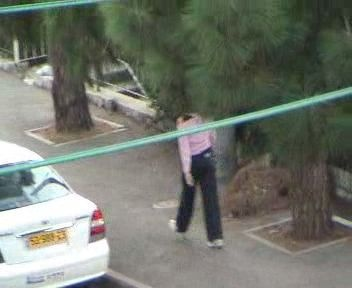

In [6]:
video = load_video("data/woman/")

player = VideoViewer()
player.play(video)

## 2. Tracking using Template Matching

In this task we will implement a simple object tracking algorithm using template matching. We will match the object reference patch to the search region in each new frame. 

We will select a region of interest (ROI) in the first frame and use it as a template to track the object in subsequent frames. We will visualize the tracking results by drawing a rectangle around the detected object in each frame.

The first thing that we will do is to define a class interface for a tracker. A tracker is a stateful algorithm, so OOP is a good fit. We will define a class `Tracker` with the following methods:
- `initialize(self, frame: np.ndarray, bounding_box: Tuple[int, int, int, int])`: constructor that takes an image and a bounding box as input. The bounding box is a tuple of four integers (x, y, width, height) that defines the region of interest in the image.
- `update(self, frame: np.ndarray)`: method that takes a new frame as input and returns the updated position of the object in the frame.
- `draw(self, frame: np.ndarray)`: method that takes a new frame as input and draws a rectangle around the detected object in the frame.
- `position(self)`: method that returns the current position of the object in the frame.

Even though Python is a dynamically typed language and does not require base classes, we will use this abstract class as a base class for our tracker. This will allow us to easily switch between different tracking algorithms in the future. 

In [7]:

class Tracker:
    def __init__(self):
        pass
    
    def initialize(self, frame, bbox):
        pass
    
    def update(self, frame):
        pass
    
    def draw(self, frame):
        pass
    
    def position(self):
        pass

Now, we will first try out cutting a reference patch from the first frame and visualize it.  Load the `bicycle` sequence and cut a patch from the first frame for the bounding box (x, y, width, height) = (154.0,94.0,18.0,48.0). Keep in mind that we will work in grayscale this time, so convert the image to grayscale using `cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)`. Use the `imshow` function to display the patch.

**Note:** The bounding box is defined as (x, y, width, height), where (x, y) is the top-left corner of the bounding box. Be careful with the order of the coordinates when slicing the image.

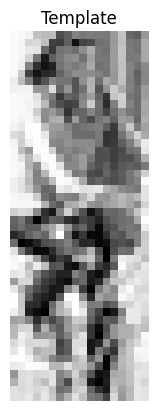

In [9]:
video = load_video("data/bicycle/")
frame = cv2.cvtColor(video[0], cv2.COLOR_BGR2GRAY)

bbox = [154.0, 94.0, 18.0, 48.0]
x, y, w, h = bbox

template = frame[int(y):int(y+h), int(x):int(x+w)]

plt.imshow(template, cmap="gray")
plt.title("Template")
plt.axis("off")
plt.show()

In the following code, we will crop patches using a helper function that pads the patch when it extends outside the image. We keep this helper as provided code because later trackers use it repeatedly.

In [10]:
def get_patch(image, bbox, replicate=True):
    """
    Extract a patch from a grayscale image.

    Parameters
    ----------
    image : np.ndarray
        Grayscale image.
    bbox : list or tuple
        Bounding box in [x, y, width, height] format.
    replicate : bool
        If True, use edge-value padding. Otherwise, use zero padding.

    Returns
    -------
    np.ndarray
        Patch with size approximately (height, width). For integer bboxes this is exact.
    """
    assert len(image.shape) == 2, "Image must be grayscale"

    x0 = int(round(bbox[0]))
    y0 = int(round(bbox[1]))
    w = int(round(bbox[2]))
    h = int(round(bbox[3]))
    x1 = x0 + w
    y1 = y0 + h

    # Padding needed before clipping to image boundaries.
    x0_pad = max(0, -x0)
    y0_pad = max(0, -y0)
    x1_pad = max(0, x1 - image.shape[1])
    y1_pad = max(0, y1 - image.shape[0])

    # Clip coordinates to the image.
    x0_clip = max(0, x0)
    y0_clip = max(0, y0)
    x1_clip = min(image.shape[1], x1)
    y1_clip = min(image.shape[0], y1)

    patch = image[y0_clip:y1_clip, x0_clip:x1_clip]

    if patch.shape[0] == 0 or patch.shape[1] == 0:
        return np.zeros((h, w), dtype=image.dtype)

    border_type = cv2.BORDER_REPLICATE if replicate else cv2.BORDER_CONSTANT
    return cv2.copyMakeBorder(
        patch,
        y0_pad,
        y1_pad,
        x0_pad,
        x1_pad,
        border_type,
        value=0,
    )

We can now match the patch to the same frame using `cv2.matchTemplate`. Instead of matching directly against the entire frame in a real tracker, we will later restrict the search to a region around the previous position.

**Task:** compute the template matching similarity map and visualize the best match.

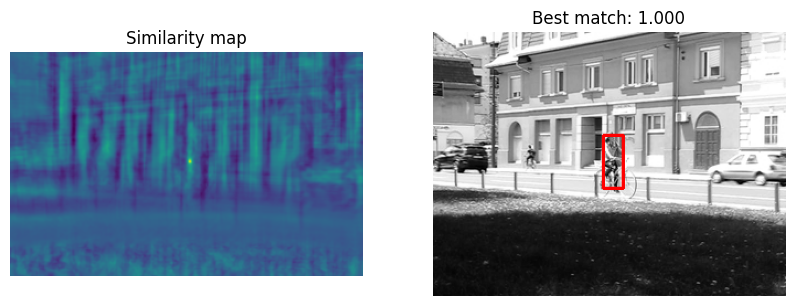

In [11]:
result = cv2.matchTemplate(frame, template, cv2.TM_CCOEFF_NORMED)

_, max_val, _, max_loc = cv2.minMaxLoc(result)

vis = cv2.cvtColor(frame.copy(), cv2.COLOR_GRAY2RGB)
x, y = max_loc
w, h = template.shape[1], template.shape[0]

cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(result)
plt.title("Similarity map")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(vis)
plt.title(f"Best match: {max_val:.3f}")
plt.axis("off")

plt.show()

Now implement the `TemplateTracker` class.

## Required behavior

- `initialize(frame, bbox)`: save the initial template and target state.
- `update(frame)`: search around previous position, compute similarity, update position.
- `draw(frame)`: draw predicted box.
- `position()`: return current predicted box.

## Recommended design

1. Use a **local search region** around the previous position (do not search full frame every time).
2. Keep target size fixed for this baseline tracker.
3. Convert all tracking frames to grayscale before matching.
4. Keep code modular: one helper for search-region construction and one helper for peak decoding.

## Minimal validation

Before running full video, test these cases:
1. Same frame twice: displacement should be near zero.
2. Known synthetic shift: predicted displacement should have correct sign and axis.
3. Search near borders: tracker should not crash due to patch out-of-bounds.

## Reflection

After testing, briefly explain:
- why this tracker drifts,
- why it fails under appearance change,
- how local search size affects speed vs robustness.

In [12]:
class TemplateTracker(Tracker):
    def __init__(self, search_size=100):
        super().__init__()
        self._template = None
        self._bbox = None
        self._position = None
        self._search_size = search_size

    def initialize(self, frame, bbox):
        if len(frame.shape) == 3:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        self._bbox = list(map(float, bbox))
        self._position = self._bbox.copy()

        x, y, w, h = self._bbox
        self._template = get_patch(frame, [x, y, w, h])

    def update(self, frame):
        if len(frame.shape) == 3:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        x, y, w, h = self._position
        cx = x + w / 2
        cy = y + h / 2

        search_w = w + 2 * self._search_size
        search_h = h + 2 * self._search_size

        search_x = cx - search_w / 2
        search_y = cy - search_h / 2

        search_region = get_patch(frame, [search_x, search_y, search_w, search_h])

        result = cv2.matchTemplate(search_region, self._template, cv2.TM_CCOEFF_NORMED)
        _, _, _, max_loc = cv2.minMaxLoc(result)

        new_x = search_x + max_loc[0]
        new_y = search_y + max_loc[1]

        self._position = [new_x, new_y, w, h]
        return self._position

    def draw(self, frame):
        x, y, w, h = map(int, map(round, self._position))
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        return frame

    def position(self):
        return self._position

We can now try running our tracker on the `bicycle` sequence. Load the video frames and create an instance of the `Tracker` class. Use a loop to read each frame and call the `update` method to update the position of the object. Use the `draw` method to draw a rectangle around the detected object in each frame. Use `imshow` to display the image and `plt.pause(0.1)` to create an animation effect.

**Question**: The tracker is not very robust, it fails soon, why is that? What can we do to improve it?

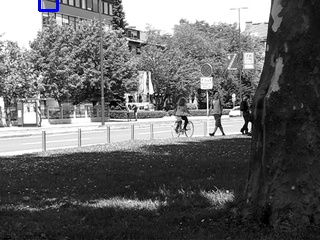

In [13]:
video = load_video("data/bicycle/")

bbox = [154.0,94.0,18.0,48.0]

tracker = TemplateTracker()
tracker.initialize(cv2.cvtColor(video[0], cv2.COLOR_BGR2GRAY), bbox)
player = VideoViewer()
for i, frame in enumerate(video[1:]):
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    bbox = tracker.update(frame)
    frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
    frame = tracker.draw(frame)
    player.show(frame)
    time.sleep(0.05)
    
    # You can shorten the video by breaking the loop
    #if i > 20:
    #    break

### Analysis

- The tracker initially follows the bicycle correctly, but after a few frames it starts tracking a different region (like the window).
- This happens because the tracker relies only on visual similarity to the original template. When the appearance of the bicycle changes (due to motion, blur, or perspective), or when another region looks similar, the tracker can choose the wrong location. Once it locks onto the wrong region, it continues searching around that incorrect position in subsequent frames, causing the error to accumulate. This behavior is known as **drift**.

## 3. Correlation Filters for Object Tracking

In this task, you will implement a grayscale correlation-filter tracker from scratch. The key idea is to learn a filter that produces a strong response at the target center and weaker response elsewhere.

## Learning goal

Translate the template-matching pipeline into a frequency-domain tracker with online model update.

## Roadmap

1. Build an analysis patch around the target.
2. Apply a cosine/Hanning window to reduce boundary artifacts.
3. Build a Gaussian desired response.
4. Compute filter in Fourier domain.
5. Apply filter to get response map and estimate displacement.
6. Update filter over time with learning rate `alpha`.

We start with an offline example on `juice` using bounding box `(131, 50, 36, 89)`.

Because DCF assumes circular correlation, windowing is important. First compare raw patch and windowed patch.

**Question**: How does analysis region size affect sensitivity to distractors and robustness to motion?

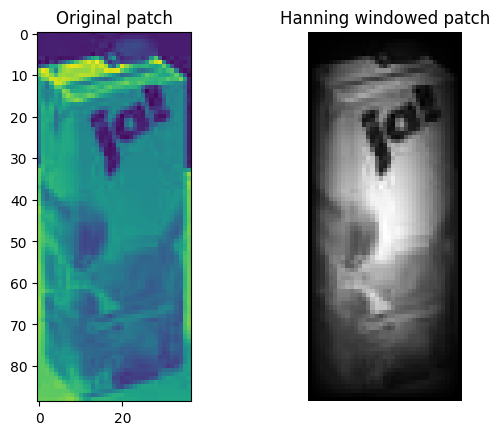

In [14]:

video = load_video("data/juice/")
frame = cv2.cvtColor(video[0], cv2.COLOR_BGR2GRAY)
bbox = [131,50,37,89]

window = cv2.createHanningWindow((int(bbox[2]), int(bbox[3])), cv2.CV_32F)

plt.subplot(1, 2, 1)
plt.imshow(get_patch(frame, bbox))
plt.title("Original patch")
plt.subplot(1, 2, 2)
plt.imshow(get_patch(frame, bbox) * window)
plt.title("Hanning windowed patch")
plt.set_cmap('gray')
plt.axis('off')
plt.show()


- The Hanning window made the edges of the patch darker/smoother. This reduces the importance of sharp borders around the cropped image.
- The tracker then focuses more on the object in the center. This helps avoid false matches caused by patch boundaries. So, it makes correlation tracking more stable.

Now compute the discriminative correlation filter in Fourier domain.

The filter is trained from a windowed target patch and a desired Gaussian response. This exploratory cell is included as a guided derivation; students should fill in the missing computations.

**Student task:** create the Gaussian peak, compute the FFTs, calculate the filter, and visualize the response.

In [15]:
def create_gauss_peak(target_size, sigma):
    w, h = target_size

    xs = np.arange(w) - w // 2
    ys = np.arange(h) - h // 2
    xx, yy = np.meshgrid(xs, ys)

    sigma_pixels = sigma * min(w, h)
    g = np.exp(-0.5 * (xx**2 + yy**2) / (sigma_pixels**2))

    g = np.roll(g, -h // 2, axis=0)
    g = np.roll(g, -w // 2, axis=1)

    return g

Now integrate the correlation filter into the full tracking loop.

### Implementation checklist

1. `initialize`:
    - define target center and analysis region,
    - build cosine window and desired Gaussian response,
    - compute initial filter in Fourier domain.

2. `update`:
    - extract patch at current center,
    - compute response map,
    - find peak and convert to displacement,
    - update center,
    - recompute filter at new location,
    - blend old/new filter with learning rate.

3. `draw` and `position`:
    - visualize and return current state.

The online update rule is:
$$
h_{t+1} = \alpha h^{\star} + (1 - \alpha) h_t,
$$
where $h^{\star}$ is the newly estimated filter at frame $t$.

### Minimal sanity checks (run before long sequence)

- No-motion check: same frame should give near-zero displacement.
- Synthetic shift check: known translation should match predicted sign and axis.
- Border check: target near image boundary should not crash patch extraction.

### Suggested extensions

- Add a confidence score (for example response peak value).
- Update model only when confidence is above threshold.
- Compare fixed analysis size vs size tied to target dimensions.
- Compare overlap curves against template matching baseline.

In [16]:
class CorrelationTracker(Tracker):
    def __init__(self, t=0.01, alpha=0.025, padding_factor=1.75, gauss_sigma=0.2):
        super().__init__()
        self.learning_rate = alpha
        self.padding_factor = padding_factor
        self.gauss_sigma = gauss_sigma
        self.cf_lambda = 0.01

    def initialize(self, frame, bbox):
        if len(frame.shape) == 3:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        x, y, w, h = list(map(float, bbox))

        self.target_w = w
        self.target_h = h
        self.center = np.array([x + w / 2, y + h / 2], dtype=np.float32)

        self.window_w = int(round(w * self.padding_factor))
        self.window_h = int(round(h * self.padding_factor))

        if self.window_w % 2 == 0:
            self.window_w += 1
        if self.window_h % 2 == 0:
            self.window_h += 1

        self.cos_window = np.outer(
            np.hanning(self.window_h),
            np.hanning(self.window_w)
        )

        g = create_gauss_peak((self.window_w, self.window_h), self.gauss_sigma)
        self.G = np.fft.fft2(g)

        patch = self._get_window(frame)
        self.H = self._train_filter(patch)

    def _get_window(self, frame):
        x = self.center[0] - self.window_w / 2
        y = self.center[1] - self.window_h / 2

        patch = get_patch(frame, [x, y, self.window_w, self.window_h])
        patch = patch.astype(np.float32) / 255.0
        patch = patch - np.mean(patch)
        patch = patch * self.cos_window

        return patch

    def _train_filter(self, patch):
        F = np.fft.fft2(patch)
        H = self.G * np.conj(F) / (F * np.conj(F) + self.cf_lambda)
        return H

    def update(self, frame):
        if len(frame.shape) == 3:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        patch = self._get_window(frame)
        F = np.fft.fft2(patch)

        response = np.real(np.fft.ifft2(F * self.H))

        max_pos = np.unravel_index(np.argmax(response), response.shape)
        dy, dx = max_pos

        if dx > self.window_w / 2:
            dx -= self.window_w
        if dy > self.window_h / 2:
            dy -= self.window_h

        self.center += np.array([dx, dy], dtype=np.float32)

        new_patch = self._get_window(frame)
        new_H = self._train_filter(new_patch)

        self.H = (
            self.learning_rate * new_H
            + (1 - self.learning_rate) * self.H
        )

        return self.position()

    def draw(self, frame):
        x, y, w, h = self.position()
        x, y, w, h = map(int, map(round, [x, y, w, h]))

        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        return frame

    def position(self):
        x = self.center[0] - self.target_w / 2
        y = self.center[1] - self.target_h / 2
        return [float(x), float(y), float(self.target_w), float(self.target_h)]

Experiment with updates, region size. Visualize the sequence to see the performance as you have done before. You can now use sequence `juice` with the bounding box (x, y, width, height) = (131,50,36,89).

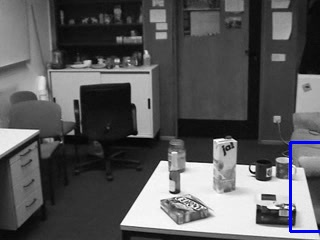

In [50]:
video = load_video("data/juice/")
bbox = [131,50,36,89]
tracker = CorrelationTracker()

tracker.initialize(cv2.cvtColor(video[0], cv2.COLOR_BGR2GRAY), bbox)
player = VideoViewer()

for i, frame in enumerate(video[1:]):
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    bbox = tracker.update(frame)
    frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
    frame = tracker.draw(frame)
    player.show(frame)
    time.sleep(0.1)
    
    if i > 200:
        break


### Correlation Tracker Explanation

- The tracker learns what the object looks like and creates a filter for it. In each new frame, it searches for the place where the filter gives the strongest response. Then the box is moved to that strongest position. The tracker also updates slowly so it can adapt when the object changes a little.

- The results were better compared to the previous template matching approach, since the blue box stayed on the bottle for most of the video instead of drifting away.

## 4. Object Tracking Evaluation

In this task, we will evaluate the performance of our object tracking algorithms. We will calculate the tracking accuracy and visualize the results. We will also compare the performance of the template matching and correlation filter methods. To compare the performance of methods, we first have to compare each one to the ground truth. We will use the ground truth data provided in the  folder of each sequence. Modern standards for visual tracking are moving to segmentaton masks, but we will use the much simpler bound-box annotations. The ground truth data is stored in a text file with the following format:

```
x0 y0 width0 height0
x1 y1 width1 height1
...
```

where `x` and `y` are the coordinates of the top-left corner of the bounding box, and `width` and `height` are the dimensions of the bounding box. We will use this data to calculate the tracking accuracy and visualize the results. We will then compare the performance of the template matching and correlation filter methods.

Load the ground truth data using the `np.loadtxt` function and store it in a variable. You can then visualize the ground truth data on a video in the same way as we did for the tracking results.

Now, we will calculate the intersection over union (IoU) between the predicted bounding box and the ground truth bounding box. The IoU is defined as the area of intersection divided by the area of union. We will use this metric to evaluate the performance of our object tracking algorithms. The IoU is a common metric for evaluating object detection and tracking algorithms. It is defined as:
$$
IoU = \frac{Area_{intersection}}{Area_{union}}
$$
where $Area_{intersection}$ is the area of intersection between the predicted bounding box and the ground truth bounding box, and $Area_{union}$ is the area of union between the predicted bounding box and the ground truth bounding box. Since both bounding boxes are rectangles, we can calculate the area of intersection and union using the following formulas: 
$$
Area_{intersection} = max(0, min(x1 + w1, x2 + w2) - max(x1, x2)) * max(0, min(y1 + h1, y2 + h2) - max(y1, y2))
$$
$$
Area_{union} = Area_{predicted} + Area_{ground\_truth} - Area_{intersection}
$$
where $(x1, y1, w1, h1)$ are the coordinates of the predicted bounding box and $(x2, y2, w2, h2)$ are the coordinates of the ground truth bounding box. Experiment with different bounding boxes and print the IoU value.

In [18]:
def compute_iou(bbox1, bbox2):
    x1, y1, w1, h1 = bbox1
    x2, y2, w2, h2 = bbox2

    xa = max(x1, x2)
    ya = max(y1, y2)
    xb = min(x1 + w1, x2 + w2)
    yb = min(y1 + h1, y2 + h2)

    inter_w = max(0, xb - xa)
    inter_h = max(0, yb - ya)
    intersection = inter_w * inter_h

    area1 = w1 * h1
    area2 = w2 * h2
    union = area1 + area2 - intersection

    if union <= 0:
        return 0.0

    return intersection / union

Using all of the material, we can now load a ground truth trajectory, initialize the tracker using the information for the first frame. Then we let the tracker run and calculate the IoU for each frame. The overlap over time is then visualized over time using Matplotlib. Use the `plot` function to plot the IoU values and set the title and labels for the axes.

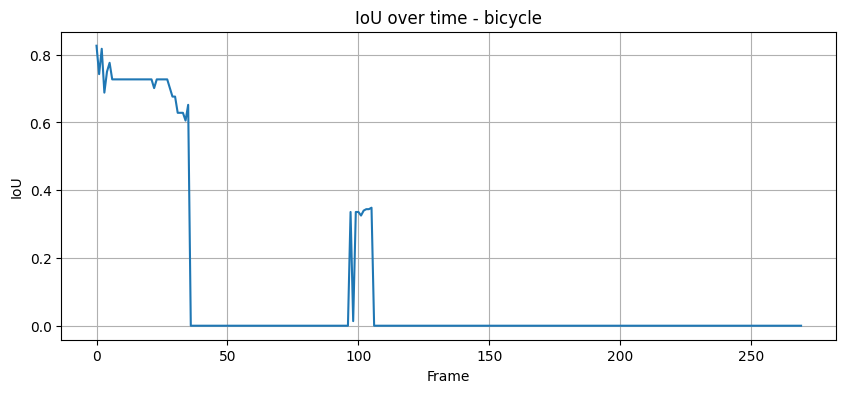

Average IoU: 0.10554192584481242


In [19]:
def load_groundtruth(sequence_path):
    import os
    import numpy as np

    possible_names = [
        "groundtruth.txt",
        "groundtruth_rect.txt",
        "gt.txt",
        "groundtruth_rect.1.txt"
    ]

    for name in possible_names:
        path = os.path.join(sequence_path, name)
        if os.path.exists(path):
            return np.loadtxt(path, delimiter=",")

    raise FileNotFoundError(f"No ground truth file found in {sequence_path}")

sequence = "bicycle"

video = load_video(f"data/{sequence}/")
gt = load_groundtruth(f"data/{sequence}/")

tracker = TemplateTracker(search_size=80)
tracker.initialize(cv2.cvtColor(video[0], cv2.COLOR_BGR2GRAY), gt[0])

ious = []

for i in range(1, len(video)):
    frame_gray = cv2.cvtColor(video[i], cv2.COLOR_BGR2GRAY)

    pred_bbox = tracker.update(frame_gray)
    iou = compute_iou(pred_bbox, gt[i])
    ious.append(iou)

plt.figure(figsize=(10, 4))
plt.plot(ious)
plt.title(f"IoU over time - {sequence}")
plt.xlabel("Frame")
plt.ylabel("IoU")
plt.grid(True)
plt.show()

print("Average IoU:", np.mean(ious))

- At the beginning, IoU is high, around 0.7–0.8, so the tracker was following the bicycle well. Then around frame 35–40, IoU drops to 0, meaning the tracker completely lost the bicycle. The small rise near frame 100 means it briefly overlapped with the bicycle again, but then failed again.

- The average IoU is low (0.105), so overall the templateTracker performed badly on the bicycle sequence.

Now, we can summarize the performance of a tracker by calculating the average IoU over all frames. We can use the `np.mean` function to calculate the *average accuracy*. Run a tracker on all provided sequences and calculate the average IoU for each sequence. You can use a loop to iterate over the sequences and store the results in a list. Print the average IoU for each sequence.

In [20]:
sequences = ["bicycle", "juice", "torus", "woman"]

results = []

for sequence in sequences:
    video = load_video(f"data/{sequence}/")
    gt = load_groundtruth(f"data/{sequence}/")

    tracker = TemplateTracker(search_size=80)
    tracker.initialize(cv2.cvtColor(video[0], cv2.COLOR_BGR2GRAY), gt[0])

    ious = []

    n = min(len(video), len(gt))

    for i in range(1, n):
        frame_gray = cv2.cvtColor(video[i], cv2.COLOR_BGR2GRAY)
        pred_bbox = tracker.update(frame_gray)
        ious.append(compute_iou(pred_bbox, gt[i]))

    avg_iou = np.mean(ious)
    results.append(avg_iou)

    print(sequence, "average IoU:", avg_iou)

print("Overall average IoU:", np.mean(results))

bicycle average IoU: 0.10554192584481242
juice average IoU: 0.3916410943457856
torus average IoU: 0.08810580836725872
woman average IoU: 0.061998714189858375
Overall average IoU: 0.16182188568692876


Run each tracker on all four provided sequences, and calculate the average accuracy over all sequences a tracker. You can use the `np.mean` function to calculate the average accuracy.

In [ ]:
sequences = ["bicycle", "juice", "woman","torus"]
results_template = {}
results_corr = {}

for seq in sequences:
    print(f"\nProcessing {seq}...")
    
    video = load_video(f"data/{seq}/")
    ground_truth = np.loadtxt(f"data/{seq}/groundtruth.txt", delimiter=',', dtype=float)
    bbox_init = ground_truth[0].tolist()
    
    tracker_template = TemplateTracker(search_size=100)
    tracker_template.initialize(video[0], bbox_init)
    ious_template = []
    for i in range(1, min(len(video), len(ground_truth))):
        try:
            tracker_template.update(video[i])
            pred_bbox = tracker_template.position()
            iou = compute_iou(pred_bbox, ground_truth[i].tolist())
            ious_template.append(iou)
        except:
            pass
    results_template[seq] = np.mean(ious_template) if ious_template else 0
    
    tracker_corr = CorrelationTracker()
    tracker_corr.initialize(video[0], bbox_init)
    ious_corr = []
    for i in range(1, min(len(video), len(ground_truth))):
        try:
            tracker_corr.update(video[i])
            pred_bbox = tracker_corr.position()
            iou = compute_iou(pred_bbox, ground_truth[i].tolist())
            ious_corr.append(iou)
        except:
            pass
    results_corr[seq] = np.mean(ious_corr) if ious_corr else 0

avg_template = np.mean(list(results_template.values()))
avg_corr = np.mean(list(results_corr.values()))

print("\n" + "=" * 50)
print("AVERAGE IoU RESULTS")
print("=" * 50)
print(f"{'Sequence':<12} {'Template Matching':<20} {'Correlation Filter':<20}")
print("-" * 50)
for seq in sequences:
    print(f"{seq:<12} {results_template[seq]:<20.4f} {results_corr[seq]:<20.4f}")
print("-" * 50)
print(f"{'AVERAGE':<12} {avg_template:<20.4f} {avg_corr:<20.4f}")
print("=" * 50)


Processing bicycle...

Processing juice...

Processing woman...

Processing torus...

AVERAGE IoU RESULTS
Sequence     Template Matching    Correlation Filter  
--------------------------------------------------
bicycle      0.0809               0.3959              
juice        0.3917               0.3784              
woman        0.0687               0.3519              
torus        0.0851               0.0943              
--------------------------------------------------
AVERAGE      0.1566               0.3051              


# 5. Optional part: Multi-channel correlation filters

In the previous part, you implemented a single-channel (grayscale) correlation filter tracker. In this optional part, you will build a **multi-channel** variant using HOG features (and optionally one extra low-resolution gray channel). You probably already know what HOG features are, so this will be a good opportunity to see how they can be used in a tracking context. The multi-channel correlation filter is a more powerful model that can capture more complex appearance variations of the target object, but it also requires more careful implementation.

## What to implement (recommended roadmap)

Implement your tracker in small steps and verify each step before moving on.

1. **Model geometry**:
Define a fixed model window size (for example from a `search_size` parameter) and derive HOG cell/block layout from it.

2. **Context sampling**:
Use the target box and a `padding_factor` to define a context window in image coordinates. Crop this context and resize it to the fixed model window.

3. **Feature tensor**:
Compute HOG on the resized patch and reshape descriptors into a 3D tensor `(rows, cols, channels)`. Optionally concatenate a downsampled gray channel.

4. **Desired response**:
Build a centered Gaussian response map in model coordinates and transform it to Fourier domain.

5. **Filter initialization**:
    Given feature FFT `F`, compute multi-channel filter
    $$
    \mathcal{H} = \frac{\mathcal{G}\,\mathcal{F}^{*}}{\sum_c \mathcal{F}_c\mathcal{F}_c^{*} + \lambda}
    $$
    where `c` indexes feature channels.

6. **Localization (update step)**:
    Compute response with
    $$
    I = \mathcal{F}^{-1}\left(\sum_c \mathcal{F}_c\mathcal{H}_c\right)
    $$
    then find peak location and convert displacement from model coordinates back to image coordinates.

7. **Model adaptation**:
Recompute `H_new` at the new center and update by exponential moving average:
$$
\mathcal{H}_{t+1} = (1-\alpha)\mathcal{H}_t + \alpha\mathcal{H}_{new}
$$

### Important implementation details

- **Axis convention**: Rows correspond to `y`, columns correspond to `x`. Keep this consistent when converting peak position to `(dx, dy)`.

- **Circular correlation effect**: The raw inverse-FFT response is circular. For interpretation, it is often easier to inspect a centered version (`fftshift`) when debugging.

- **Subpixel refinement**: A simple 1D parabolic fit around the peak along x and y is enough for this exercise. You do not need a complex optimizer. But you can also upsample the response map and find the maximum for better precision.

- **Numerical stability**: Use a small `lambda` in the denominator to avoid division by zero.

### Minimal debug checks you should run

Before evaluating on full sequences, verify these sanity checks:

1. **No motion test**: If two frames are identical, estimated displacement should be close to `(0, 0)`.

2. **Synthetic shift test**: Apply known translation to the frame (for example +8 px in x or y) and check whether your predicted displacement has correct sign and axis.

3. **Shape checks**: Print sizes of model window, context window, feature map, and channel count once during initialization.

### Suggested experiments

- Change `padding_factor`: how does target-to-context ratio affect robustness?
- Change `search_size`: how does model resolution affect localization precision?
- Compare with single-channel tracker on the same sequence (IoU over time).

## **HOG feature helper**

In [35]:
from skimage.feature import hog

def extract_hog_features(patch, pixels_per_cell=(8, 8), include_gray=True):
    if len(patch.shape) == 3:
        gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    else:
        gray = patch.copy()

    gray = gray.astype(np.float32) / 255.0

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=(1, 1),
        block_norm="L2-Hys",
        visualize=False,
        feature_vector=False
    )

    # Make HOG into rows x cols x channels
    if features.ndim == 5:
        features = features[:, :, 0, 0, :]
    elif features.ndim == 3:
        pass
    else:
        raise ValueError(f"Unexpected HOG shape: {features.shape}")

    if include_gray:
        rows, cols, _ = features.shape
        gray_small = cv2.resize(gray, (cols, rows))
        gray_small = gray_small[:, :, None]
        features = np.concatenate([features, gray_small], axis=2)

    return features.astype(np.float32)

## **Gaussian peak for feature map**

In [36]:
def create_gauss_peak_feature_map(size, sigma):
    rows, cols = size

    ys = np.arange(rows) - rows // 2
    xs = np.arange(cols) - cols // 2
    xx, yy = np.meshgrid(xs, ys)

    sigma_pixels = sigma * min(rows, cols)
    g = np.exp(-0.5 * (xx**2 + yy**2) / (sigma_pixels**2))

    g = np.roll(g, -rows // 2, axis=0)
    g = np.roll(g, -cols // 2, axis=1)

    return g.astype(np.float32)

## **Multi-channel correlation tracker**

In [39]:
class MultiChannelCorrelationTracker(Tracker):
    def __init__(
        self,
        search_size=128,
        alpha=0.025,
        padding_factor=2.0,
        gauss_sigma=0.2,
        pixels_per_cell=(8, 8),
        include_gray=True,
        cf_lambda=0.01
    ):
        super().__init__()

        self.search_size = search_size
        self.learning_rate = alpha
        self.padding_factor = padding_factor
        self.gauss_sigma = gauss_sigma
        self.pixels_per_cell = pixels_per_cell
        self.include_gray = include_gray
        self.cf_lambda = cf_lambda

    def initialize(self, frame, bbox):
        x, y, w, h = list(map(float, bbox))

        self.target_w = w
        self.target_h = h

        self.center = np.array(
            [x + w / 2, y + h / 2],
            dtype=np.float32
        )

        self.context_w = w * self.padding_factor
        self.context_h = h * self.padding_factor

        self.model_w = self.search_size
        self.model_h = self.search_size

        patch = self._get_resized_context(frame)
        features = self._extract_features(patch)

        self.feature_rows, self.feature_cols, self.num_channels = features.shape

        g = create_gauss_peak_feature_map(
            (self.feature_rows, self.feature_cols),
            self.gauss_sigma
        )

        self.G = np.fft.fft2(g)

        self.H = self._train_filter(features)

        print("Model window:", self.model_w, self.model_h)
        print("Context window:", self.context_w, self.context_h)
        print("Feature map:", features.shape)

    def _get_resized_context(self, frame):
        if len(frame.shape) == 3:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        patch = cv2.getRectSubPix(
            frame,
            (int(round(self.context_w)), int(round(self.context_h))),
            (float(self.center[0]), float(self.center[1]))
        )

        patch = cv2.resize(
            patch,
            (self.model_w, self.model_h),
            interpolation=cv2.INTER_LINEAR
        )

        return patch

    def _extract_features(self, patch):
        features = extract_hog_features(
            patch,
            pixels_per_cell=self.pixels_per_cell,
            include_gray=self.include_gray
        )

        hann_y = np.hanning(features.shape[0])
        hann_x = np.hanning(features.shape[1])
        cos_window = np.outer(hann_y, hann_x)

        features = features * cos_window[:, :, None]

        return features

    def _train_filter(self, features):
        F = np.fft.fft2(features, axes=(0, 1))

        denominator = np.sum(F * np.conj(F), axis=2) + self.cf_lambda

        H = np.zeros_like(F, dtype=np.complex128)

        for c in range(F.shape[2]):
            H[:, :, c] = self.G * np.conj(F[:, :, c]) / denominator

        return H

    def update(self, frame):
        patch = self._get_resized_context(frame)
        features = self._extract_features(patch)

        F = np.fft.fft2(features, axes=(0, 1))

        response_fft = np.sum(F * self.H, axis=2)
        response = np.real(np.fft.ifft2(response_fft))

        peak_y, peak_x = np.unravel_index(
            np.argmax(response),
            response.shape
        )

        dy = peak_y
        dx = peak_x

        if dx > self.feature_cols / 2:
            dx -= self.feature_cols

        if dy > self.feature_rows / 2:
            dy -= self.feature_rows

        cell_w = self.context_w / self.feature_cols
        cell_h = self.context_h / self.feature_rows

        dx_img = dx * cell_w
        dy_img = dy * cell_h

        self.center += np.array([dx_img, dy_img], dtype=np.float32)

        new_patch = self._get_resized_context(frame)
        new_features = self._extract_features(new_patch)
        H_new = self._train_filter(new_features)

        self.H = (
            (1 - self.learning_rate) * self.H
            + self.learning_rate * H_new
        )

        return self.position()

    def draw(self, frame):
        x, y, w, h = self.position()
        x, y, w, h = map(int, map(round, [x, y, w, h]))

        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 0, 255), 2)

        return frame

    def position(self):
        x = self.center[0] - self.target_w / 2
        y = self.center[1] - self.target_h / 2

        return [
            float(x),
            float(y),
            float(self.target_w),
            float(self.target_h)
        ]

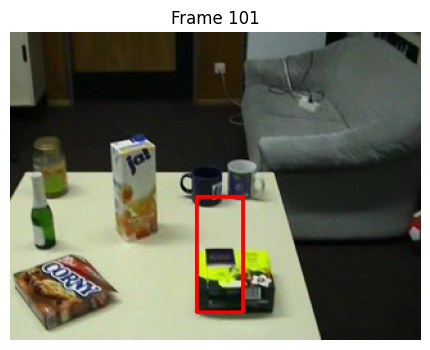

In [43]:
from IPython.display import clear_output
import time

for i, frame in enumerate(video):
    if i > 0:
        tracker.update(frame)

    vis = frame.copy()
    tracker.draw(vis)

    clear_output(wait=True)
    plt.figure(figsize=(6, 4))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {i}")
    plt.axis("off")
    plt.show()

    time.sleep(0.05)

    if i > 100:
        break

## **no-motion sanity check**

In [44]:
sequence = "juice"

video = load_video(f"data/{sequence}/")
gt = load_groundtruth(f"data/{sequence}/")

tracker = MultiChannelCorrelationTracker()
tracker.initialize(video[0], gt[0])

old_pos = tracker.position()
new_pos = tracker.update(video[0])

print("Old position:", old_pos)
print("New position:", new_pos)

dx = new_pos[0] - old_pos[0]
dy = new_pos[1] - old_pos[1]

print("Estimated displacement:", dx, dy)

Model window: 128 128
Context window: 73.0 179.294
Feature map: (16, 16, 10)
Old position: [131.2100067138672, 50.01300207519531, 36.5, 89.647]
New position: [131.2100067138672, 50.01300207519531, 36.5, 89.647]
Estimated displacement: 0.0 0.0


### Sanity Check Analysis

- In the no-motion test, the tracker predicted zero displacement, which confirms correct behavior.

- In the synthetic shift test, the tracker detected motion in the x direction but underestimated the displacement and failed to detect the y movement. This happens because the feature map has low resolution, so the tracker can only estimate motion approximately.

## **synthetic shift test**

In [45]:
sequence = "juice"

video = load_video(f"data/{sequence}/")
gt = load_groundtruth(f"data/{sequence}/")

frame = video[0]

shift_x = 8
shift_y = 5

M = np.float32([
    [1, 0, shift_x],
    [0, 1, shift_y]
])

shifted_frame = cv2.warpAffine(
    frame,
    M,
    (frame.shape[1], frame.shape[0])
)

tracker = MultiChannelCorrelationTracker()
tracker.initialize(frame, gt[0])

old_pos = tracker.position()
new_pos = tracker.update(shifted_frame)

dx = new_pos[0] - old_pos[0]
dy = new_pos[1] - old_pos[1]

print("Expected shift:", shift_x, shift_y)
print("Predicted shift:", dx, dy)

Model window: 128 128
Context window: 73.0 179.294
Feature map: (16, 16, 10)
Expected shift: 8 5
Predicted shift: 4.5625 0.0


## **Evaluation**

Model window: 128 128
Context window: 73.0 179.294
Feature map: (16, 16, 10)


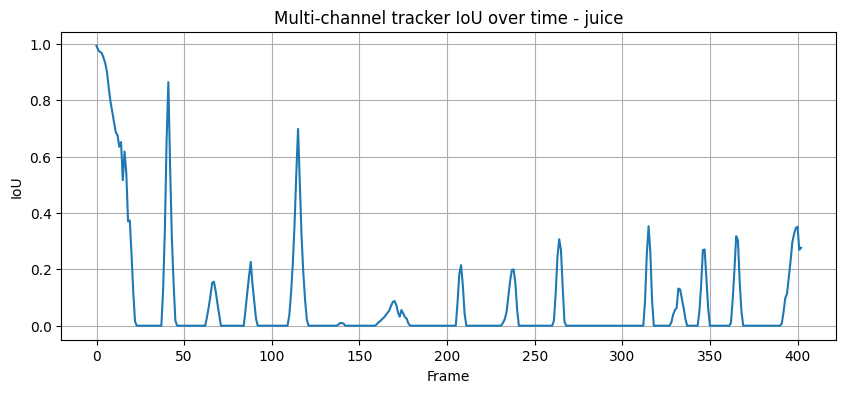

Average IoU: 0.08133262192621836


In [46]:
sequence = "juice"

video = load_video(f"data/{sequence}/")
gt = load_groundtruth(f"data/{sequence}/")

tracker = MultiChannelCorrelationTracker(
    search_size=128,
    alpha=0.025,
    padding_factor=2.0,
    gauss_sigma=0.2,
    include_gray=True
)

tracker.initialize(video[0], gt[0])

ious = []

n = min(len(video), len(gt))

for i in range(1, n):
    pred_bbox = tracker.update(video[i])
    iou = compute_iou(pred_bbox, gt[i])
    ious.append(iou)

plt.figure(figsize=(10, 4))
plt.plot(ious)
plt.title(f"Multi-channel tracker IoU over time - {sequence}")
plt.xlabel("Frame")
plt.ylabel("IoU")
plt.grid(True)
plt.show()

print("Average IoU:", np.mean(ious))

In [47]:
sequences = ["bicycle", "juice", "torus", "woman"]

results = {}

for sequence in sequences:
    video = load_video(f"data/{sequence}/")
    gt = load_groundtruth(f"data/{sequence}/")

    tracker = MultiChannelCorrelationTracker(
        search_size=128,
        alpha=0.025,
        padding_factor=2.0,
        gauss_sigma=0.2,
        include_gray=True
    )

    tracker.initialize(video[0], gt[0])

    ious = []

    n = min(len(video), len(gt))

    for i in range(1, n):
        pred_bbox = tracker.update(video[i])
        ious.append(compute_iou(pred_bbox, gt[i]))

    avg_iou = np.mean(ious)
    results[sequence] = avg_iou

    print(sequence, "Average IoU:", avg_iou)

print("Overall average IoU:", np.mean(list(results.values())))

Model window: 128 128
Context window: 36.0 96.0
Feature map: (16, 16, 10)
bicycle Average IoU: 0.1744244686706185
Model window: 128 128
Context window: 73.0 179.294
Feature map: (16, 16, 10)
juice Average IoU: 0.08133262192621836
Model window: 128 128
Context window: 98.0 100.0
Feature map: (16, 16, 10)
torus Average IoU: 0.18166171274991527
Model window: 128 128
Context window: 58.0 206.0
Feature map: (16, 16, 10)
woman Average IoU: 0.23078788465068162
Overall average IoU: 0.16705167199935844


### Multi-channel Correlation Filter Analysis

- The multi-channel tracker uses HOG features instead of only grayscale pixels. This makes the tracker stronger because HOG captures the shape and edge structure of the object. The tracker learns a filter that gives the strongest response when the object is centered.

- Compared to template matching, this method is usually more stable because it does not only depend on raw pixel similarity. The result should be better when the object changes slightly, but it can still fail if the object changes too much, disappears, or if the search region contains strong distractors.

# Conclusion

For the final part of the exercise, compare the performance of the several trackers, you can use different parameters for the correlation filter tracker, and compare it to the template matching tracker.

**You can use the built-in OpenCV tracker classes at this stage, note that these trackers are quite complex and will likely perform better than our custom implementation.**

In this case you will have to install the `opencv-contrib-python` package, which contains the extra modules for OpenCV. You can do this using pip:
```bash
pip install opencv-contrib-python
```
You can use the `cv2.TrackerKCF_create()` function to create a KCF tracker (note that KCF apparently does not work on some versions of OpenCV), or `cv2.TrackerCSRT_create()` for a CSRT tracker. The usage is similar to the one we implemented, but you will have to call the `init` method on the tracker object with the first frame and the bounding box, and then call the `update` method on each new frame.

In [ ]:
# !pip install opencv-contrib-python

Compare the performance of the different trackers by calculating the average IoU for each tracker on all sequences. You can use a loop to iterate over the trackers and store the results in a list. Print the average IoU for each tracker.

**Question**: These trackers are much more robust than the one we implemented, why is that? What are the main differences between the two methods? What are the advantages and disadvantages of each method?


### Comparison of Tracking Methods

The different trackers show clear differences in performance and robustness. Template matching is the simplest approach but performs poorly when the object changes or moves. Correlation filters improve performance by learning and updating the object appearance over time. OpenCV trackers are the most advanced and robust because they use more sophisticated techniques and optimizations.

| Aspect | Template Matching | Correlation Filter | OpenCV Trackers |
|--------|------------------|--------------------|------------------|
| Idea | Matches fixed image patch | Learns a filter for the object | Uses advanced optimized algorithms |
| Robustness | Low (fails easily) | Medium (adapts over time) | High (handles complex changes) |
| Adaptation | No adaptation | Updates model over time | Advanced adaptation strategies |
| Speed | Fast | Fast | Medium to fast |
| Accuracy | Low | Better | High |
| Failure cases | Appearance change, motion, distractors | Drift if wrong update | More resistant but still not perfect |
| Advantage | Simple and easy to understand | Better tracking than template | Best performance and stability |
| Disadvantage | Not reliable | Still can drift | More complex and harder to understand |